In [1]:
# ============================================================
# 13B_ROMA_AURORA_source_aware_unified_comparison.ipynb
# Source-aware ROMA-AURORA Final Paper Tables and Figures
#
# Purpose:
# 1. Fix Notebook 13 benchmark-name collision problem.
# 2. Preserve source-specific benchmark columns:
#      ROMA_B12_ma_timing_equal_weight
#      AURORA_B12_ma_timing_equal_weight
# 3. Use ROMA benchmarks for ROMA-vs-benchmark claims.
# 4. Use AURORA benchmarks for AURORA-vs-benchmark claims.
# 5. Use common aligned strict-test dates for ROMA-vs-AURORA.
# 6. Export final source-aware paper tables, figures, and manuscript assets.
#
# Main interpretation:
# - ROMA = leakage-controlled regime-template baseline.
# - AURORA10-UAMV-B = uncertainty-aware allocation method.
# - ROMA_B12 = strongest ROMA R2/R3 timing benchmark.
# - Same-named benchmarks from ROMA and AURORA are NOT merged.
#
# Educational/research use only.
# Not personalized financial advice.
# ============================================================

from __future__ import annotations

import json
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone

warnings.filterwarnings("ignore")

# ============================================================
# 0. Colab setup
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Google Drive mount skipped or failed.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

# ============================================================
# 1. Paths and run configuration
# ============================================================

PROJECT_CODE = "ROMA_AURORA_TWETF"
ROMA_CODE = "ROMA_TWETF"
AURORA_CODE = "AURORA_TWETF"

PUBLICATION_ROOT = Path("/content/drive/MyDrive/AURORA_TWETF")

# Completed ROMA R3 run.
ROMA_R3_RUN_ID = "20260625_031440"

ROMA_R3_ROOT = (
    PUBLICATION_ROOT
    / "outputs"
    / ROMA_CODE
    / "statistical_significance_block_bootstrap"
    / f"run_{ROMA_R3_RUN_ID}"
)

NOTEBOOK13_INPUT_INDEX_PATH = ROMA_R3_ROOT / "NOTEBOOK13_ROMA_AURORA_INPUT_INDEX.csv"

# Previous Notebook 13 run, used only as diagnostic context if needed.
NOTEBOOK13_RUN_ID = "20260625_064802"
NOTEBOOK13_ROOT = (
    PUBLICATION_ROOT
    / "outputs"
    / PROJECT_CODE
    / "unified_paper_comparison"
    / f"run_{NOTEBOOK13_RUN_ID}"
)

# AURORA reference runs.
AURORA_NOTEBOOK10_RUN_ID = "20260624_100748"
AURORA_NOTEBOOK11_RUN_ID = "20260624_124834"
AURORA_NOTEBOOK12_RUN_ID = "20260624_142307"

AURORA_NOTEBOOK10_ROOT = (
    PUBLICATION_ROOT
    / "outputs"
    / AURORA_CODE
    / "uncertainty_aware_mean_variance_allocation"
    / f"run_{AURORA_NOTEBOOK10_RUN_ID}"
)

AURORA_NOTEBOOK11_ROOT = (
    PUBLICATION_ROOT
    / "outputs"
    / AURORA_CODE
    / "statistical_significance_block_bootstrap"
    / f"run_{AURORA_NOTEBOOK11_RUN_ID}"
)

AURORA_NOTEBOOK12_ROOT = (
    PUBLICATION_ROOT
    / "outputs"
    / AURORA_CODE
    / "paper_tables_figures_manuscript_assets"
    / f"run_{AURORA_NOTEBOOK12_RUN_ID}"
)

OUTPUT_ROOT = PUBLICATION_ROOT / "outputs" / PROJECT_CODE
TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"
FIGURE_DIR = OUTPUT_ROOT / "figures"
MANUSCRIPT_DIR = OUTPUT_ROOT / "manuscript_assets"

RUN_TIMESTAMP = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

RUN_ROOT = OUTPUT_ROOT / "source_aware_unified_paper_comparison" / f"run_{RUN_ID}"

TABLE_RUN_DIR = RUN_ROOT / "tables"
REPORT_RUN_DIR = RUN_ROOT / "reports"
FIGURE_RUN_DIR = RUN_ROOT / "figures"
PAPER_FIGURE_DIR = RUN_ROOT / "paper_figures"
MANUSCRIPT_RUN_DIR = RUN_ROOT / "manuscript_assets"
RETURN_DIR = RUN_ROOT / "returns"

for d in [
    OUTPUT_ROOT,
    TABLE_DIR,
    REPORT_DIR,
    FIGURE_DIR,
    MANUSCRIPT_DIR,
    RUN_ROOT,
    TABLE_RUN_DIR,
    REPORT_RUN_DIR,
    FIGURE_RUN_DIR,
    PAPER_FIGURE_DIR,
    MANUSCRIPT_RUN_DIR,
    RETURN_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("Notebook 13B: Source-aware ROMA-AURORA Final Comparison")
print("=" * 80)
print("Timestamp UTC              :", RUN_TIMESTAMP)
print("Run ID                     :", RUN_ID)
print("ROMA R3 run ID             :", ROMA_R3_RUN_ID)
print("Notebook13 input index     :", NOTEBOOK13_INPUT_INDEX_PATH)
print("Previous Notebook13 root   :", NOTEBOOK13_ROOT)
print("AURORA Notebook10 root     :", AURORA_NOTEBOOK10_ROOT)
print("AURORA Notebook11 root     :", AURORA_NOTEBOOK11_ROOT)
print("AURORA Notebook12 root     :", AURORA_NOTEBOOK12_ROOT)
print("Run root                   :", RUN_ROOT)
print("=" * 80)

if not NOTEBOOK13_INPUT_INDEX_PATH.exists():
    raise FileNotFoundError(f"Missing Notebook 13 input index: {NOTEBOOK13_INPUT_INDEX_PATH}")

# ============================================================
# 2. Global settings
# ============================================================

ANNUALIZATION = 252

PRIMARY_ROMA_POLICY = "ROMA_P4_balanced_regime_blend"
ROMA_20D_POLICY = "ROMA_P2_20d_only_return_seeking"
ROMA_BLEND_POLICY = "ROMA_P0_validation_selected_20_60_blend"

PRIMARY_AURORA_POLICY = "AURORA10_UAMV_B_more60_defensive"
VALIDATION_SELECTED_AURORA_POLICY = "AURORA10_validation_selected_UAMV"

# Source-aware benchmark names.
ROMA_B12 = "ROMA_B12_ma_timing_equal_weight"
ROMA_B6 = "ROMA_B6_00881_only"
ROMA_B3 = "ROMA_B3_0050_only"
ROMA_B1 = "ROMA_B1_equal_weight_all_etfs"
ROMA_B10 = "ROMA_B10_momentum_top2_63d"
ROMA_B15 = "ROMA_B15_minimum_variance_126d"

AURORA_B12 = "AURORA_B12_ma_timing_equal_weight"
AURORA_B6 = "AURORA_B6_00881_only"
AURORA_B3 = "AURORA_B3_0050_only"
AURORA_B1 = "AURORA_B1_equal_weight_all_etfs"
AURORA_B10 = "AURORA_B10_momentum_top2_63d"
AURORA_B16 = "AURORA_B16_minimum_variance_126d"

AURORA_POLICIES = [
    "AURORA10_UAMV_B_more60_defensive",
    "AURORA10_UAMV_D_low_turnover",
    "AURORA10_UAMV_E_no_regime_tilt_control",
    "AURORA10_UAMV_A_balanced",
    "AURORA10_UAMV_C_more60_growth",
    "AURORA10_validation_selected_UAMV",
]

ROMA_POLICIES = [
    "ROMA_P4_balanced_regime_blend",
    "ROMA_P2_20d_only_return_seeking",
    "ROMA_P0_validation_selected_20_60_blend",
    "ROMA_P1_more20_return_seeking",
    "ROMA_P3_conservative_blend",
]

FINAL_POLICY_ORDER = [
    PRIMARY_AURORA_POLICY,
    "AURORA10_UAMV_D_low_turnover",
    "AURORA10_UAMV_E_no_regime_tilt_control",
    "AURORA10_UAMV_A_balanced",
    "AURORA10_UAMV_C_more60_growth",
    VALIDATION_SELECTED_AURORA_POLICY,
    PRIMARY_ROMA_POLICY,
    ROMA_20D_POLICY,
    ROMA_BLEND_POLICY,
    ROMA_B12,
    ROMA_B6,
    ROMA_B3,
    ROMA_B1,
    ROMA_B10,
    ROMA_B15,
    AURORA_B12,
    AURORA_B6,
    AURORA_B3,
    AURORA_B1,
    AURORA_B10,
    AURORA_B16,
]

DISPLAY_NAMES = {
    PRIMARY_AURORA_POLICY: "AURORA10-UAMV-B",
    "AURORA10_UAMV_D_low_turnover": "AURORA10-UAMV-D",
    "AURORA10_UAMV_E_no_regime_tilt_control": "AURORA10-UAMV-E",
    "AURORA10_UAMV_A_balanced": "AURORA10-UAMV-A",
    "AURORA10_UAMV_C_more60_growth": "AURORA10-UAMV-C",
    VALIDATION_SELECTED_AURORA_POLICY: "AURORA10 validation-selected UAMV",

    PRIMARY_ROMA_POLICY: "ROMA-P4 balanced regime",
    ROMA_20D_POLICY: "ROMA-P2 20d return-seeking",
    ROMA_BLEND_POLICY: "ROMA-P0 20/60 blend",
    "ROMA_P1_more20_return_seeking": "ROMA-P1 more-20d return-seeking",
    "ROMA_P3_conservative_blend": "ROMA-P3 conservative blend",

    ROMA_B12: "ROMA-B12 MA timing equal-weight",
    ROMA_B6: "ROMA-B6 00881 only",
    ROMA_B3: "ROMA-B3 0050 only",
    ROMA_B1: "ROMA-B1 equal-weight all ETFs",
    ROMA_B10: "ROMA-B10 momentum top-2",
    ROMA_B15: "ROMA-B15 minimum variance",

    AURORA_B12: "AURORA-B12 MA timing equal-weight",
    AURORA_B6: "AURORA-B6 00881 only",
    AURORA_B3: "AURORA-B3 0050 only",
    AURORA_B1: "AURORA-B1 equal-weight all ETFs",
    AURORA_B10: "AURORA-B10 momentum top-2",
    AURORA_B16: "AURORA-B16 minimum variance",
}

POLICY_GROUPS = {
    PRIMARY_AURORA_POLICY: "AURORA final method",
    "AURORA10_UAMV_D_low_turnover": "AURORA sensitivity",
    "AURORA10_UAMV_E_no_regime_tilt_control": "AURORA sensitivity",
    "AURORA10_UAMV_A_balanced": "AURORA sensitivity",
    "AURORA10_UAMV_C_more60_growth": "AURORA sensitivity",
    VALIDATION_SELECTED_AURORA_POLICY: "AURORA validation-selected comparator",

    PRIMARY_ROMA_POLICY: "ROMA regime-template baseline",
    ROMA_20D_POLICY: "ROMA regime-template baseline",
    ROMA_BLEND_POLICY: "ROMA regime-template baseline",
    "ROMA_P1_more20_return_seeking": "ROMA regime-template baseline",
    "ROMA_P3_conservative_blend": "ROMA regime-template baseline",

    ROMA_B12: "ROMA technical benchmark",
    ROMA_B6: "ROMA single-ETF benchmark",
    ROMA_B3: "ROMA single-ETF benchmark",
    ROMA_B1: "ROMA passive benchmark",
    ROMA_B10: "ROMA technical benchmark",
    ROMA_B15: "ROMA risk-based benchmark",

    AURORA_B12: "AURORA technical benchmark",
    AURORA_B6: "AURORA single-ETF benchmark",
    AURORA_B3: "AURORA single-ETF benchmark",
    AURORA_B1: "AURORA passive benchmark",
    AURORA_B10: "AURORA technical benchmark",
    AURORA_B16: "AURORA risk-based benchmark",
}

# ============================================================
# 3. Utility functions
# ============================================================

def save_json(path, obj):
    Path(path).write_text(
        json.dumps(obj, indent=2, ensure_ascii=False, default=str),
        encoding="utf-8",
    )

def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    h = hashlib.sha256()

    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)

    return h.hexdigest()

def make_file_manifest(root):
    root = Path(root)
    rows = []

    for p in sorted(root.rglob("*")):
        if p.is_file():
            stat = p.stat()
            rows.append({
                "path": p.relative_to(root).as_posix(),
                "size_bytes": int(stat.st_size),
                "modified_utc": datetime.fromtimestamp(
                    stat.st_mtime,
                    timezone.utc,
                ).strftime("%Y-%m-%dT%H:%M:%SZ"),
                "sha256": sha256_file(p),
            })

    return pd.DataFrame(rows)

def safe_name(x):
    return (
        str(x)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace(" ", "_")
        .replace(".", "_")
        .replace("%", "pct")
        .replace("-", "_")
        .replace("+", "plus")
    )

def read_table(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)

    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)

    raise ValueError(f"Unsupported file type: {path}")

def write_markdown(path, text):
    Path(path).write_text(text, encoding="utf-8")

def load_matrix(path):
    df = read_table(path)

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.set_index("date")
    else:
        df.index = pd.to_datetime(df.index)

    df = df.sort_index()
    return df

def calculate_drawdown(equity):
    equity = pd.Series(equity).astype(float)
    running_max = equity.cummax()
    return equity / running_max - 1.0

def make_equity(r):
    r = pd.Series(r).dropna().astype(float)
    return (1.0 + r).cumprod()

def make_drawdown(r):
    return calculate_drawdown(make_equity(r))

def performance_metrics(r, annualization=ANNUALIZATION):
    r = pd.Series(r).dropna().astype(float)

    if len(r) == 0:
        return {
            "n_days": 0,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
            "total_return": np.nan,
            "annual_return": np.nan,
            "annual_volatility": np.nan,
            "sharpe": np.nan,
            "sortino": np.nan,
            "max_drawdown": np.nan,
            "calmar": np.nan,
            "final_equity": np.nan,
            "mean_daily_return": np.nan,
            "daily_volatility": np.nan,
            "positive_day_rate": np.nan,
            "worst_daily_return": np.nan,
            "best_daily_return": np.nan,
        }

    r.index = pd.to_datetime(r.index)
    equity = make_equity(r)

    n = len(r)
    total_return = float(equity.iloc[-1] - 1.0)
    annual_return = float(equity.iloc[-1] ** (annualization / n) - 1.0)

    daily_vol = float(r.std(ddof=1)) if n > 1 else np.nan
    annual_vol = float(daily_vol * np.sqrt(annualization)) if np.isfinite(daily_vol) else np.nan

    mean_daily = float(r.mean())
    sharpe = float((mean_daily / daily_vol) * np.sqrt(annualization)) if daily_vol and daily_vol > 0 else np.nan

    downside = r[r < 0]
    downside_vol = float(downside.std(ddof=1)) if len(downside) > 1 else np.nan
    sortino = float((mean_daily / downside_vol) * np.sqrt(annualization)) if np.isfinite(downside_vol) and downside_vol > 0 else np.nan

    dd = calculate_drawdown(equity)
    max_dd = float(dd.min())

    calmar = float(annual_return / abs(max_dd)) if max_dd < 0 else np.nan

    return {
        "n_days": int(n),
        "start_date": r.index.min(),
        "end_date": r.index.max(),
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_volatility": annual_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_dd,
        "calmar": calmar,
        "final_equity": float(equity.iloc[-1]),
        "mean_daily_return": mean_daily,
        "daily_volatility": daily_vol,
        "positive_day_rate": float((r > 0).mean()),
        "worst_daily_return": float(r.min()),
        "best_daily_return": float(r.max()),
    }

def paired_difference_metrics(strategy_returns, benchmark_returns):
    s = pd.Series(strategy_returns).dropna().astype(float)
    b = pd.Series(benchmark_returns).dropna().astype(float)

    common = s.index.intersection(b.index).sort_values()
    s = s.loc[common]
    b = b.loc[common]

    ps = performance_metrics(s)
    pb = performance_metrics(b)
    excess = s - b

    return {
        "n_days": int(len(common)),
        "strategy_total_return": ps["total_return"],
        "benchmark_total_return": pb["total_return"],
        "diff_total_return": ps["total_return"] - pb["total_return"],
        "strategy_annual_return": ps["annual_return"],
        "benchmark_annual_return": pb["annual_return"],
        "diff_annual_return": ps["annual_return"] - pb["annual_return"],
        "strategy_annual_volatility": ps["annual_volatility"],
        "benchmark_annual_volatility": pb["annual_volatility"],
        "diff_annual_volatility": ps["annual_volatility"] - pb["annual_volatility"],
        "strategy_sharpe": ps["sharpe"],
        "benchmark_sharpe": pb["sharpe"],
        "diff_sharpe": ps["sharpe"] - pb["sharpe"],
        "strategy_sortino": ps["sortino"],
        "benchmark_sortino": pb["sortino"],
        "diff_sortino": ps["sortino"] - pb["sortino"],
        "strategy_max_drawdown": ps["max_drawdown"],
        "benchmark_max_drawdown": pb["max_drawdown"],
        "drawdown_improvement": ps["max_drawdown"] - pb["max_drawdown"],
        "strategy_calmar": ps["calmar"],
        "benchmark_calmar": pb["calmar"],
        "diff_calmar": ps["calmar"] - pb["calmar"],
        "annualized_mean_excess_return": float(excess.mean() * ANNUALIZATION),
        "mean_daily_excess_return": float(excess.mean()),
        "daily_tracking_error": float(excess.std(ddof=1)),
        "excess_return_hit_rate": float((excess > 0).mean()),
    }

def build_performance_table(mat):
    rows = []

    for policy in mat.columns:
        m = performance_metrics(mat[policy])
        m["policy_name"] = policy
        m["display_name"] = DISPLAY_NAMES.get(policy, policy)
        m["policy_group"] = POLICY_GROUPS.get(policy, "other")
        rows.append(m)

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out["rank_total_return"] = out["total_return"].rank(ascending=False, method="min")
    out["rank_annual_return"] = out["annual_return"].rank(ascending=False, method="min")
    out["rank_sharpe"] = out["sharpe"].rank(ascending=False, method="min")
    out["rank_sortino"] = out["sortino"].rank(ascending=False, method="min")
    out["rank_max_drawdown"] = out["max_drawdown"].rank(ascending=False, method="min")
    out["rank_calmar"] = out["calmar"].rank(ascending=False, method="min")

    out["composite_rank"] = (
        out["rank_total_return"]
        + out["rank_annual_return"]
        + out["rank_sharpe"]
        + out["rank_sortino"]
        + out["rank_max_drawdown"]
        + out["rank_calmar"]
    ) / 6.0

    out = out.sort_values(
        ["composite_rank", "sharpe", "total_return"],
        ascending=[True, False, False],
    ).reset_index(drop=True)

    return out

def save_table(df, local_name, global_name):
    local_path = TABLE_RUN_DIR / local_name
    global_path = TABLE_DIR / global_name

    df.to_csv(local_path, index=False)
    df.to_csv(global_path, index=False)

    return local_path, global_path

def prefix_benchmark_columns(mat, source_prefix):
    out = mat.copy()
    rename = {}

    for col in out.columns:
        if col.startswith("ROMA_") or col.startswith("AURORA10_"):
            rename[col] = col
        else:
            rename[col] = f"{source_prefix}_{col}"

    out = out.rename(columns=rename)
    return out, pd.DataFrame([
        {
            "source_prefix": source_prefix,
            "original_column": old,
            "source_aware_column": new,
            "changed": old != new,
        }
        for old, new in rename.items()
    ])

def normalize_bool_columns(df, cols):
    out = df.copy()

    for c in cols:
        if c in out.columns and out[c].dtype == object:
            out[c] = out[c].astype(str).str.lower().map({
                "true": True,
                "false": False,
            }).fillna(False)

    return out

# ============================================================
# 4. Load Notebook 13 input index and source matrices
# ============================================================

print("\n" + "=" * 80)
print("Step 1: Loading Notebook 13 input index and source matrices")
print("=" * 80)

nb13_index = pd.read_csv(NOTEBOOK13_INPUT_INDEX_PATH)

if nb13_index.empty:
    raise ValueError("Notebook 13 input index is empty.")

nb13 = nb13_index.iloc[0].to_dict()

roma_test_matrix_path = Path(nb13["roma_test_return_matrix_path"])
roma_oos_matrix_path = Path(nb13["roma_oos_return_matrix_path"])

aurora_test_matrix_path = (
    Path(nb13["aurora_test_return_matrix_path"])
    if pd.notna(nb13.get("aurora_test_return_matrix_path"))
    else None
)

roma_pairwise_path = Path(nb13["observed_pairwise_differences_path"])
roma_decision_table_path = Path(nb13["paper_decision_table_path"])
roma_bootstrap_summary_path = Path(nb13["primary_bootstrap_summary_path"])
roma_diagnostic_summary_path = Path(nb13["diagnostic_summary_path"])

roma_test_mat_raw = load_matrix(roma_test_matrix_path)
roma_oos_mat_raw = load_matrix(roma_oos_matrix_path)

if aurora_test_matrix_path is not None and aurora_test_matrix_path.exists():
    aurora_test_mat_raw = load_matrix(aurora_test_matrix_path)
else:
    aurora_test_mat_raw = pd.DataFrame()

roma_pairwise = read_table(roma_pairwise_path)
roma_decision = read_table(roma_decision_table_path)
roma_bootstrap = read_table(roma_bootstrap_summary_path)
roma_diagnostic = read_table(roma_diagnostic_summary_path)

print("ROMA strict-test raw matrix :", roma_test_mat_raw.shape, roma_test_mat_raw.index.min(), "to", roma_test_mat_raw.index.max())
print("ROMA OOS raw matrix         :", roma_oos_mat_raw.shape, roma_oos_mat_raw.index.min(), "to", roma_oos_mat_raw.index.max())

if len(aurora_test_mat_raw):
    print("AURORA strict-test raw matrix:", aurora_test_mat_raw.shape, aurora_test_mat_raw.index.min(), "to", aurora_test_mat_raw.index.max())
else:
    print("AURORA strict-test raw matrix: not available")

print("ROMA decision table:", roma_decision.shape)
print("ROMA bootstrap table:", roma_bootstrap.shape)

# ============================================================
# 5. Source-aware benchmark names
# ============================================================

print("\n" + "=" * 80)
print("Step 2: Creating source-aware benchmark columns")
print("=" * 80)

roma_test_mat, roma_rename_audit = prefix_benchmark_columns(roma_test_mat_raw, "ROMA")
roma_oos_mat, roma_oos_rename_audit = prefix_benchmark_columns(roma_oos_mat_raw, "ROMA")

if len(aurora_test_mat_raw):
    aurora_test_mat, aurora_rename_audit = prefix_benchmark_columns(aurora_test_mat_raw, "AURORA")
else:
    aurora_test_mat = pd.DataFrame()
    aurora_rename_audit = pd.DataFrame()

rename_audit_df = pd.concat(
    [
        roma_rename_audit.assign(matrix="roma_test"),
        roma_oos_rename_audit.assign(matrix="roma_oos"),
        aurora_rename_audit.assign(matrix="aurora_test"),
    ],
    axis=0,
    ignore_index=True,
)

save_table(
    rename_audit_df,
    local_name="notebook13B_source_aware_column_rename_audit.csv",
    global_name=f"table_13B_01_source_aware_column_rename_audit_{RUN_ID}.csv",
)

print("ROMA source-aware columns:")
print(roma_test_mat.columns.tolist())

if len(aurora_test_mat):
    print("AURORA source-aware columns:")
    print(aurora_test_mat.columns.tolist())

# ============================================================
# 6. Source audit: verify B12 no longer collides
# ============================================================

print("\n" + "=" * 80)
print("Step 3: Source audit for B12 and duplicate benchmarks")
print("=" * 80)

source_audit_rows = []

audit_pairs = [
    ("B12_ma_timing_equal_weight", ROMA_B12, AURORA_B12),
    ("B6_00881_only", ROMA_B6, AURORA_B6),
    ("B3_0050_only", ROMA_B3, AURORA_B3),
    ("B1_equal_weight_all_etfs", ROMA_B1, AURORA_B1),
    ("B10_momentum_top2_63d", ROMA_B10, AURORA_B10),
]

common_audit_dates = roma_test_mat.index

if len(aurora_test_mat):
    common_audit_dates = common_audit_dates.intersection(aurora_test_mat.index).sort_values()

for label, roma_col, aurora_col in audit_pairs:
    row = {
        "benchmark_label": label,
        "roma_source_column": roma_col,
        "aurora_source_column": aurora_col,
        "has_roma_column": roma_col in roma_test_mat.columns,
        "has_aurora_column": aurora_col in aurora_test_mat.columns if len(aurora_test_mat) else False,
        "n_common_dates": int(len(common_audit_dates)),
    }

    if row["has_roma_column"]:
        rp = performance_metrics(roma_test_mat.loc[common_audit_dates, roma_col])
        row.update({
            "roma_total_return": rp["total_return"],
            "roma_sharpe": rp["sharpe"],
            "roma_max_drawdown": rp["max_drawdown"],
        })

    if row["has_aurora_column"]:
        ap = performance_metrics(aurora_test_mat.loc[common_audit_dates, aurora_col])
        row.update({
            "aurora_total_return": ap["total_return"],
            "aurora_sharpe": ap["sharpe"],
            "aurora_max_drawdown": ap["max_drawdown"],
        })

    if row["has_roma_column"] and row["has_aurora_column"]:
        diff = paired_difference_metrics(
            roma_test_mat.loc[common_audit_dates, roma_col],
            aurora_test_mat.loc[common_audit_dates, aurora_col],
        )
        row.update({
            "roma_minus_aurora_total_return": diff["diff_total_return"],
            "roma_minus_aurora_sharpe": diff["diff_sharpe"],
            "roma_minus_aurora_drawdown_improvement": diff["drawdown_improvement"],
            "series_are_identical": bool(
                np.allclose(
                    roma_test_mat.loc[common_audit_dates, roma_col].values,
                    aurora_test_mat.loc[common_audit_dates, aurora_col].values,
                    equal_nan=True,
                )
            ),
        })

    source_audit_rows.append(row)

source_audit_df = pd.DataFrame(source_audit_rows)

save_table(
    source_audit_df,
    local_name="notebook13B_benchmark_source_audit.csv",
    global_name=f"table_13B_02_benchmark_source_audit_{RUN_ID}.csv",
)

print("Benchmark source audit:")
print(source_audit_df.to_string(index=False))

# ============================================================
# 7. Build source-aware unified strict-test matrix
# ============================================================

print("\n" + "=" * 80)
print("Step 4: Building source-aware unified strict-test matrix")
print("=" * 80)

common_dates = roma_test_mat.index

if len(aurora_test_mat):
    common_dates = common_dates.intersection(aurora_test_mat.index).sort_values()

print("Common strict-test dates:", len(common_dates), common_dates.min(), "to", common_dates.max())

source_aware_mat = pd.DataFrame(index=common_dates)

# Add AURORA policies and AURORA-prefixed benchmarks.
if len(aurora_test_mat):
    for col in aurora_test_mat.columns:
        source_aware_mat[col] = aurora_test_mat.loc[common_dates, col]

# Add ROMA policies and ROMA-prefixed benchmarks.
for col in roma_test_mat.columns:
    source_aware_mat[col] = roma_test_mat.loc[common_dates, col]

ordered_cols = [c for c in FINAL_POLICY_ORDER if c in source_aware_mat.columns]
remaining_cols = [c for c in source_aware_mat.columns if c not in ordered_cols]
source_aware_mat = source_aware_mat[ordered_cols + remaining_cols].copy()

source_aware_matrix_path = RETURN_DIR / "notebook13B_source_aware_strict_test_return_matrix.parquet"
source_aware_matrix_csv_path = RETURN_DIR / "notebook13B_source_aware_strict_test_return_matrix.csv"

source_aware_mat.to_parquet(source_aware_matrix_path)
source_aware_mat.to_csv(source_aware_matrix_csv_path)

print("Source-aware strict-test matrix:", source_aware_mat.shape)
print("Columns:")
print(source_aware_mat.columns.tolist())

# ============================================================
# 8. Performance tables
# ============================================================

print("\n" + "=" * 80)
print("Step 5: Building source-aware performance tables")
print("=" * 80)

all_perf = build_performance_table(source_aware_mat)

all_perf["paper_order"] = all_perf["policy_name"].map(
    {p: i for i, p in enumerate(FINAL_POLICY_ORDER)}
).fillna(999).astype(int)

focused_policies = [p for p in FINAL_POLICY_ORDER if p in all_perf["policy_name"].values]

focused_perf = all_perf[all_perf["policy_name"].isin(focused_policies)].copy()
focused_perf = focused_perf.sort_values(
    ["composite_rank", "paper_order"],
    ascending=[True, True],
).reset_index(drop=True)

# A smaller final table with only the most important paper rows.
final_core_policies = [
    PRIMARY_AURORA_POLICY,
    "AURORA10_UAMV_D_low_turnover",
    "AURORA10_UAMV_E_no_regime_tilt_control",
    VALIDATION_SELECTED_AURORA_POLICY,
    PRIMARY_ROMA_POLICY,
    ROMA_20D_POLICY,
    ROMA_B12,
    ROMA_B6,
    ROMA_B3,
    ROMA_B1,
    AURORA_B12,
    AURORA_B6,
    AURORA_B3,
    AURORA_B1,
]

core_perf = all_perf[all_perf["policy_name"].isin(final_core_policies)].copy()
core_perf["paper_order"] = core_perf["policy_name"].map(
    {p: i for i, p in enumerate(final_core_policies)}
).fillna(999).astype(int)
core_perf = core_perf.sort_values(["paper_order"]).reset_index(drop=True)

compact_cols = [
    "policy_name",
    "display_name",
    "policy_group",
    "n_days",
    "total_return",
    "annual_return",
    "annual_volatility",
    "sharpe",
    "sortino",
    "max_drawdown",
    "calmar",
    "composite_rank",
]

rounded_core_perf = core_perf[compact_cols].copy()
for c in [
    "total_return",
    "annual_return",
    "annual_volatility",
    "sharpe",
    "sortino",
    "max_drawdown",
    "calmar",
    "composite_rank",
]:
    rounded_core_perf[c] = rounded_core_perf[c].astype(float).round(4)

save_table(
    all_perf,
    local_name="notebook13B_all_source_aware_performance.csv",
    global_name=f"table_13B_03_all_source_aware_performance_{RUN_ID}.csv",
)

save_table(
    focused_perf,
    local_name="notebook13B_focused_source_aware_performance.csv",
    global_name=f"table_13B_04_focused_source_aware_performance_{RUN_ID}.csv",
)

save_table(
    core_perf,
    local_name="notebook13B_core_source_aware_performance.csv",
    global_name=f"table_13B_05_core_source_aware_performance_{RUN_ID}.csv",
)

save_table(
    rounded_core_perf,
    local_name="notebook13B_core_source_aware_performance_rounded.csv",
    global_name=f"table_13B_06_core_source_aware_performance_rounded_{RUN_ID}.csv",
)

print("Core source-aware performance table:")
print(rounded_core_perf.to_string(index=False))

# ============================================================
# 9. Observed pairwise comparisons
# ============================================================

print("\n" + "=" * 80)
print("Step 6: Building observed pairwise evidence")
print("=" * 80)

pairwise_specs = [
    # AURORA vs ROMA
    (PRIMARY_AURORA_POLICY, PRIMARY_ROMA_POLICY, "AURORA10-UAMV-B vs ROMA-P4 baseline"),
    (PRIMARY_AURORA_POLICY, ROMA_20D_POLICY, "AURORA10-UAMV-B vs ROMA-P2 20d baseline"),

    # ROMA vs ROMA-source benchmarks
    (PRIMARY_ROMA_POLICY, ROMA_B12, "ROMA-P4 vs ROMA-B12 timing benchmark"),
    (PRIMARY_ROMA_POLICY, ROMA_B6, "ROMA-P4 vs ROMA-B6 00881 benchmark"),
    (PRIMARY_ROMA_POLICY, ROMA_B3, "ROMA-P4 vs ROMA-B3 0050 benchmark"),
    (PRIMARY_ROMA_POLICY, ROMA_B1, "ROMA-P4 vs ROMA-B1 equal-weight benchmark"),
    (PRIMARY_ROMA_POLICY, ROMA_B10, "ROMA-P4 vs ROMA-B10 momentum benchmark"),
    (PRIMARY_ROMA_POLICY, ROMA_B15, "ROMA-P4 vs ROMA-B15 minimum-variance benchmark"),

    # AURORA vs AURORA-source benchmarks
    (PRIMARY_AURORA_POLICY, AURORA_B12, "AURORA10-UAMV-B vs AURORA-B12 timing benchmark"),
    (PRIMARY_AURORA_POLICY, AURORA_B6, "AURORA10-UAMV-B vs AURORA-B6 00881 benchmark"),
    (PRIMARY_AURORA_POLICY, AURORA_B3, "AURORA10-UAMV-B vs AURORA-B3 0050 benchmark"),
    (PRIMARY_AURORA_POLICY, AURORA_B1, "AURORA10-UAMV-B vs AURORA-B1 equal-weight benchmark"),
    (PRIMARY_AURORA_POLICY, AURORA_B10, "AURORA10-UAMV-B vs AURORA-B10 momentum benchmark"),
    (PRIMARY_AURORA_POLICY, AURORA_B16, "AURORA10-UAMV-B vs AURORA-B16 minimum-variance benchmark"),

    # Source-difference audits
    (ROMA_B12, AURORA_B12, "ROMA-B12 vs AURORA-B12 source audit"),
    (ROMA_B1, AURORA_B1, "ROMA-B1 vs AURORA-B1 source audit"),
]

pairwise_rows = []

for strategy, benchmark, label in pairwise_specs:
    if strategy not in source_aware_mat.columns or benchmark not in source_aware_mat.columns:
        continue

    m = paired_difference_metrics(source_aware_mat[strategy], source_aware_mat[benchmark])
    pairwise_rows.append({
        "comparison_label": label,
        "strategy_policy": strategy,
        "strategy_display_name": DISPLAY_NAMES.get(strategy, strategy),
        "benchmark_policy": benchmark,
        "benchmark_display_name": DISPLAY_NAMES.get(benchmark, benchmark),
        **m,
    })

observed_pairwise_df = pd.DataFrame(pairwise_rows)

save_table(
    observed_pairwise_df,
    local_name="notebook13B_source_aware_observed_pairwise_differences.csv",
    global_name=f"table_13B_07_source_aware_observed_pairwise_differences_{RUN_ID}.csv",
)

print("Observed source-aware pairwise differences:")
print(
    observed_pairwise_df[
        [
            "comparison_label",
            "strategy_display_name",
            "benchmark_display_name",
            "n_days",
            "diff_total_return",
            "diff_sharpe",
            "diff_sortino",
            "drawdown_improvement",
            "diff_calmar",
            "annualized_mean_excess_return",
        ]
    ].to_string(index=False)
)

# ============================================================
# 10. Statistical evidence from R3, source-aware relabeling
# ============================================================

print("\n" + "=" * 80)
print("Step 7: Building source-aware statistical evidence summary")
print("=" * 80)

decision = roma_decision.copy()

decision = normalize_bool_columns(
    decision,
    ["significant_positive_95", "significant_negative_95", "not_significant_95"],
)

stat_rows = []

def decision_label(row):
    if "decision" in row and pd.notna(row["decision"]):
        return row["decision"]
    if bool(row.get("significant_positive_95", False)):
        return "significantly_positive_at_95pct_bootstrap"
    if bool(row.get("significant_negative_95", False)):
        return "significantly_negative_at_95pct_bootstrap"
    return "not_significant_at_95pct_bootstrap"

def add_r3_decision(strategy, benchmark, label, final_strategy=None, final_benchmark=None, flip=False):
    rows = decision[
        (decision["strategy_policy"] == strategy)
        & (decision["benchmark_policy"] == benchmark)
    ].copy()

    if rows.empty:
        print("No R3 decision rows found for:", strategy, "vs", benchmark)
        return

    for _, r in rows.iterrows():
        observed = float(r["observed"])
        ci2 = float(r["ci_2p5"])
        ci97 = float(r["ci_97p5"])

        source_decision = decision_label(r)

        if flip:
            obs = -observed
            lo = -ci97
            hi = -ci2

            if source_decision == "significantly_positive_at_95pct_bootstrap":
                dec = "significantly_negative_at_95pct_bootstrap"
            elif source_decision == "significantly_negative_at_95pct_bootstrap":
                dec = "significantly_positive_at_95pct_bootstrap"
            else:
                dec = "not_significant_at_95pct_bootstrap"
        else:
            obs = observed
            lo = ci2
            hi = ci97
            dec = source_decision

        s_name = final_strategy if final_strategy is not None else strategy
        b_name = final_benchmark if final_benchmark is not None else benchmark

        metric = r["metric"]

        if metric == "drawdown_improvement":
            meaning = "Positive means strategy has less severe maximum drawdown."
        elif metric == "diff_total_return":
            meaning = "Positive means strategy has higher cumulative return."
        elif metric == "diff_sharpe":
            meaning = "Positive means strategy has higher Sharpe ratio."
        elif metric == "diff_sortino":
            meaning = "Positive means strategy has higher Sortino ratio."
        elif metric == "diff_calmar":
            meaning = "Positive means strategy has higher Calmar ratio."
        elif metric == "annualized_mean_excess_return":
            meaning = "Positive means strategy has higher mean daily return annualized."
        else:
            meaning = "Positive favors strategy."

        stat_rows.append({
            "comparison_label": label,
            "strategy_policy": s_name,
            "strategy_display_name": DISPLAY_NAMES.get(s_name, s_name),
            "comparator_policy": b_name,
            "comparator_display_name": DISPLAY_NAMES.get(b_name, b_name),
            "metric": metric,
            "observed": obs,
            "ci_2p5": lo,
            "ci_97p5": hi,
            "decision": dec,
            "metric_meaning": meaning,
            "source": "ROMA_R3_block_bootstrap_relabelled_source_aware",
        })

# ROMA vs ROMA-source B12 from R3. R3 benchmark was unprefixed B12.
add_r3_decision(
    PRIMARY_ROMA_POLICY,
    "B12_ma_timing_equal_weight",
    "ROMA-P4 vs ROMA-B12 timing benchmark",
    final_strategy=PRIMARY_ROMA_POLICY,
    final_benchmark=ROMA_B12,
    flip=False,
)

# ROMA vs selected ROMA-source benchmarks from R3.
for raw_benchmark, prefixed_benchmark, label in [
    ("B6_00881_only", ROMA_B6, "ROMA-P4 vs ROMA-B6 00881 benchmark"),
    ("B3_0050_only", ROMA_B3, "ROMA-P4 vs ROMA-B3 0050 benchmark"),
    ("B1_equal_weight_all_etfs", ROMA_B1, "ROMA-P4 vs ROMA-B1 equal-weight benchmark"),
    ("B10_momentum_top2_63d", ROMA_B10, "ROMA-P4 vs ROMA-B10 momentum benchmark"),
    ("B15_minimum_variance_126d", ROMA_B15, "ROMA-P4 vs ROMA-B15 minimum-variance benchmark"),
]:
    add_r3_decision(
        PRIMARY_ROMA_POLICY,
        raw_benchmark,
        label,
        final_strategy=PRIMARY_ROMA_POLICY,
        final_benchmark=prefixed_benchmark,
        flip=False,
    )

# ROMA vs AURORA from R3.
add_r3_decision(
    PRIMARY_ROMA_POLICY,
    PRIMARY_AURORA_POLICY,
    "ROMA-P4 vs AURORA10-UAMV-B",
    final_strategy=PRIMARY_ROMA_POLICY,
    final_benchmark=PRIMARY_AURORA_POLICY,
    flip=False,
)

# AURORA-centric flipped view.
add_r3_decision(
    PRIMARY_ROMA_POLICY,
    PRIMARY_AURORA_POLICY,
    "AURORA10-UAMV-B vs ROMA-P4",
    final_strategy=PRIMARY_AURORA_POLICY,
    final_benchmark=PRIMARY_ROMA_POLICY,
    flip=True,
)

statistical_evidence_df = pd.DataFrame(stat_rows)

rounded_statistical_evidence_df = statistical_evidence_df.copy()
for c in ["observed", "ci_2p5", "ci_97p5"]:
    if c in rounded_statistical_evidence_df.columns:
        rounded_statistical_evidence_df[c] = rounded_statistical_evidence_df[c].astype(float).round(4)

save_table(
    statistical_evidence_df,
    local_name="notebook13B_source_aware_statistical_evidence.csv",
    global_name=f"table_13B_08_source_aware_statistical_evidence_{RUN_ID}.csv",
)

save_table(
    rounded_statistical_evidence_df,
    local_name="notebook13B_source_aware_statistical_evidence_rounded.csv",
    global_name=f"table_13B_09_source_aware_statistical_evidence_rounded_{RUN_ID}.csv",
)

print("Source-aware statistical evidence:")
print(
    rounded_statistical_evidence_df[
        [
            "comparison_label",
            "strategy_display_name",
            "comparator_display_name",
            "metric",
            "observed",
            "ci_2p5",
            "ci_97p5",
            "decision",
        ]
    ].to_string(index=False)
)

# ============================================================
# 11. Claim checklist
# ============================================================

print("\n" + "=" * 80)
print("Step 8: Source-aware claim checklist")
print("=" * 80)

claim_rows = [
    {
        "claim": "ROMA-P4 does not statistically outperform its own ROMA-B12 moving-average timing benchmark.",
        "supported": True,
        "evidence": (
            "R3 source-aware relabeling shows ROMA-P4 vs ROMA-B12 has no statistically significant "
            "advantage in total return, Sharpe, Sortino, drawdown improvement, Calmar, or annualized mean excess return."
        ),
        "safe_paper_wording": (
            "Under aligned strict-test evaluation, the ROMA regime-template baseline did not show "
            "a statistically significant advantage over its moving-average timing benchmark."
        ),
        "avoid_wording": "ROMA is superior to timing benchmarks.",
    },
    {
        "claim": "AURORA10-UAMV-B significantly improves risk-adjusted and downside-risk behavior relative to ROMA-P4.",
        "supported": True,
        "evidence": (
            "The flipped AURORA10-UAMV-B vs ROMA-P4 R3 decision table shows significantly positive "
            "Sharpe, Sortino, and drawdown improvement at the 95% bootstrap level."
        ),
        "safe_paper_wording": (
            "Compared with the ROMA regime-template baseline, AURORA10-UAMV-B achieved significantly "
            "stronger Sharpe, Sortino, and maximum-drawdown behavior."
        ),
        "avoid_wording": "AURORA guarantees better future investment performance.",
    },
    {
        "claim": "AURORA10-UAMV-B is not total-return dominant.",
        "supported": True,
        "evidence": (
            "AURORA10-UAMV-B has lower observed total return than ROMA-P4 and high-return ETF benchmarks, "
            "and total-return differences are not statistically significant in the ROMA-vs-AURORA bootstrap comparison."
        ),
        "safe_paper_wording": (
            "AURORA10-UAMV-B should be interpreted as a downside-risk control layer rather than a "
            "return-maximizing allocation rule."
        ),
        "avoid_wording": "AURORA maximizes returns or beats all benchmarks in total return.",
    },
    {
        "claim": "Regime forecasting alone is insufficient for robust ETF allocation.",
        "supported": True,
        "evidence": (
            "ROMA uses leakage-controlled regime probabilities with simple allocation templates but fails to dominate "
            "strong timing benchmarks; AURORA improves risk behavior through the uncertainty-aware allocation layer."
        ),
        "safe_paper_wording": (
            "The results indicate that probabilistic regime forecasts require a carefully designed uncertainty-aware "
            "allocation layer to translate signals into robust portfolio behavior."
        ),
        "avoid_wording": "Forecasting accuracy alone explains the allocation results.",
    },
    {
        "claim": "Notebook 13B fixes the Notebook 13 benchmark-name collision.",
        "supported": True,
        "evidence": (
            "Source-aware columns preserve ROMA_B12 and AURORA_B12 separately, preventing same-named benchmark overwrites."
        ),
        "safe_paper_wording": (
            "For benchmark comparisons, source-specific benchmark series were preserved rather than merged by name."
        ),
        "avoid_wording": "All same-named benchmarks are identical across notebooks.",
    },
]

claim_checklist_df = pd.DataFrame(claim_rows)

save_table(
    claim_checklist_df,
    local_name="notebook13B_claim_checklist.csv",
    global_name=f"table_13B_10_claim_checklist_{RUN_ID}.csv",
)

print("Claim checklist:")
print(claim_checklist_df.to_string(index=False))

# ============================================================
# 12. Methodology progression
# ============================================================

print("\n" + "=" * 80)
print("Step 9: Methodology progression table")
print("=" * 80)

progression_rows = [
    {
        "stage": "ROMA R1",
        "method": "Purged walk-forward ROMA regime probability rebuild",
        "purpose": "Create leakage-controlled regime probabilities using the shared AURORA feature-label dataset.",
        "main_finding": "20-day regime signal was more usable than the weak 60-day signal.",
        "paper_role": "Forecasting baseline construction.",
    },
    {
        "stage": "ROMA R2",
        "method": "Pre-defined regime-template allocation",
        "purpose": "Convert ROMA probabilities into ETF weights using interpretable return-seeking templates.",
        "main_finding": "Best ROMA policy did not dominate its own moving-average timing benchmark.",
        "paper_role": "Negative baseline / ablation.",
    },
    {
        "stage": "ROMA R3",
        "method": "Paired circular block bootstrap inference",
        "purpose": "Test whether ROMA outperformed benchmarks or AURORA.",
        "main_finding": "ROMA showed no statistically significant advantage over ROMA-B12 and was significantly weaker than AURORA on Sharpe, Sortino, and drawdown.",
        "paper_role": "Statistical evidence for insufficiency of simple regime-template mapping.",
    },
    {
        "stage": "AURORA Notebook 10",
        "method": "Uncertainty-aware mean-variance allocation",
        "purpose": "Use regime probabilities, uncertainty, bearish risk, shrinkage, and constraints to construct risk-aware ETF weights.",
        "main_finding": "AURORA10-UAMV-B improved risk-adjusted behavior and downside-risk control while sacrificing total return.",
        "paper_role": "Final proposed allocation method.",
    },
    {
        "stage": "AURORA Notebook 11",
        "method": "Block bootstrap inference for AURORA",
        "purpose": "Test AURORA10-UAMV-B against primary benchmarks.",
        "main_finding": "The strongest supported AURORA-only claim is maximum-drawdown reduction, not total-return superiority.",
        "paper_role": "Main AURORA statistical support.",
    },
    {
        "stage": "Notebook 13B",
        "method": "Source-aware ROMA-AURORA comparison",
        "purpose": "Preserve source-specific benchmark series and produce final paper tables.",
        "main_finding": "Benchmark namespace preservation is necessary; AURORA is stronger than ROMA on risk metrics, while ROMA does not statistically beat its timing benchmark.",
        "paper_role": "Final manuscript evidence synthesis.",
    },
]

progression_df = pd.DataFrame(progression_rows)

save_table(
    progression_df,
    local_name="notebook13B_methodology_progression.csv",
    global_name=f"table_13B_11_methodology_progression_{RUN_ID}.csv",
)

print("Methodology progression:")
print(progression_df.to_string(index=False))

# ============================================================
# 13. Figures
# ============================================================

print("\n" + "=" * 80)
print("Step 10: Creating source-aware paper figures")
print("=" * 80)

figure_records = []

def save_figure_record(path, figure_id, title, caption):
    figure_records.append({
        "figure_id": figure_id,
        "path": str(path),
        "title": title,
        "caption": caption,
    })

plot_policies = [
    PRIMARY_AURORA_POLICY,
    PRIMARY_ROMA_POLICY,
    ROMA_B12,
    ROMA_B6,
    ROMA_B3,
    ROMA_B1,
    AURORA_B6,
    AURORA_B1,
]

plot_policies = [p for p in plot_policies if p in source_aware_mat.columns]

# Figure 13B.1 Equity curves
plt.figure(figsize=(12, 6))
for policy in plot_policies:
    eq = make_equity(source_aware_mat[policy])
    plt.plot(eq.index, eq.values, linewidth=1.7, label=DISPLAY_NAMES.get(policy, policy))

plt.title("Source-aware strict-test equity curves")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
fig1_path = PAPER_FIGURE_DIR / "figure13B_01_source_aware_equity_curves.png"
plt.savefig(fig1_path, dpi=220)
plt.close()

save_figure_record(
    fig1_path,
    "Figure 13B.1",
    "Source-aware strict-test equity curves",
    "Equity curves for AURORA10-UAMV-B, ROMA-P4, and source-specific ROMA/AURORA benchmarks on the aligned strict-test period.",
)

# Figure 13B.2 Drawdowns
plt.figure(figsize=(12, 6))
for policy in plot_policies:
    dd = make_drawdown(source_aware_mat[policy])
    plt.plot(dd.index, dd.values, linewidth=1.7, label=DISPLAY_NAMES.get(policy, policy))

plt.title("Source-aware strict-test drawdowns")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
fig2_path = PAPER_FIGURE_DIR / "figure13B_02_source_aware_drawdowns.png"
plt.savefig(fig2_path, dpi=220)
plt.close()

save_figure_record(
    fig2_path,
    "Figure 13B.2",
    "Source-aware strict-test drawdowns",
    "Drawdown curves showing downside-risk behavior after preserving source-specific benchmark series.",
)

# Figure 13B.3 Sharpe bar
bar_perf = core_perf[core_perf["policy_name"].isin(plot_policies)].copy()
bar_perf = bar_perf.sort_values("sharpe", ascending=True)

colors = []
for p in bar_perf["policy_name"]:
    if p == PRIMARY_AURORA_POLICY:
        colors.append("#1f77b4")
    elif p == PRIMARY_ROMA_POLICY:
        colors.append("#d62728")
    elif p.startswith("ROMA_B"):
        colors.append("#ff7f0e")
    elif p.startswith("AURORA_B"):
        colors.append("#7f7f7f")
    else:
        colors.append("#aaaaaa")

plt.figure(figsize=(10, 6))
plt.barh(bar_perf["display_name"], bar_perf["sharpe"], color=colors)
plt.xlabel("Sharpe ratio")
plt.title("Source-aware strict-test Sharpe comparison")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
fig3_path = PAPER_FIGURE_DIR / "figure13B_03_source_aware_sharpe_bar.png"
plt.savefig(fig3_path, dpi=220)
plt.close()

save_figure_record(
    fig3_path,
    "Figure 13B.3",
    "Source-aware strict-test Sharpe comparison",
    "Sharpe comparison for AURORA, ROMA, and source-specific benchmarks.",
)

# Figure 13B.4 Max drawdown bar
bar_perf = core_perf[core_perf["policy_name"].isin(plot_policies)].copy()
bar_perf = bar_perf.sort_values("max_drawdown", ascending=True)

colors = []
for p in bar_perf["policy_name"]:
    if p == PRIMARY_AURORA_POLICY:
        colors.append("#1f77b4")
    elif p == PRIMARY_ROMA_POLICY:
        colors.append("#d62728")
    elif p.startswith("ROMA_B"):
        colors.append("#ff7f0e")
    elif p.startswith("AURORA_B"):
        colors.append("#7f7f7f")
    else:
        colors.append("#aaaaaa")

plt.figure(figsize=(10, 6))
plt.barh(bar_perf["display_name"], bar_perf["max_drawdown"], color=colors)
plt.xlabel("Maximum drawdown")
plt.title("Source-aware strict-test maximum drawdown comparison")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
fig4_path = PAPER_FIGURE_DIR / "figure13B_04_source_aware_max_drawdown_bar.png"
plt.savefig(fig4_path, dpi=220)
plt.close()

save_figure_record(
    fig4_path,
    "Figure 13B.4",
    "Source-aware strict-test maximum drawdown comparison",
    "Maximum drawdown comparison. Less negative values indicate smaller drawdowns.",
)

# Figure 13B.5 Source audit scatter
audit_plot = source_audit_df.dropna(subset=["roma_total_return", "aurora_total_return"], how="any").copy()

if len(audit_plot):
    x = audit_plot["roma_total_return"]
    y = audit_plot["aurora_total_return"]

    plt.figure(figsize=(7, 6))
    plt.scatter(x, y, s=90, color="#9467bd")

    minv = min(x.min(), y.min())
    maxv = max(x.max(), y.max())
    plt.plot([minv, maxv], [minv, maxv], linestyle="--", color="black", linewidth=1)

    for _, row in audit_plot.iterrows():
        plt.text(
            row["roma_total_return"],
            row["aurora_total_return"],
            row["benchmark_label"],
            fontsize=8,
            ha="left",
            va="bottom",
        )

    plt.xlabel("ROMA-source benchmark total return")
    plt.ylabel("AURORA-source benchmark total return")
    plt.title("Source audit: same benchmark names can have different series")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fig5_path = PAPER_FIGURE_DIR / "figure13B_05_benchmark_source_audit_scatter.png"
    plt.savefig(fig5_path, dpi=220)
    plt.close()

    save_figure_record(
        fig5_path,
        "Figure 13B.5",
        "Benchmark source audit",
        "Audit plot showing that same-named benchmarks can differ across ROMA and AURORA pipelines and should not be merged by name.",
    )

# Figure 13B.6 Statistical evidence heatmap
if len(rounded_statistical_evidence_df):
    heat = rounded_statistical_evidence_df[
        rounded_statistical_evidence_df["metric"].isin([
            "diff_total_return",
            "diff_sharpe",
            "diff_sortino",
            "drawdown_improvement",
            "diff_calmar",
            "annualized_mean_excess_return",
        ])
    ].copy()

    heat_pivot = heat.pivot_table(
        index="comparison_label",
        columns="metric",
        values="observed",
        aggfunc="first",
    )

    plt.figure(figsize=(13, max(5, 0.45 * len(heat_pivot))))
    if HAS_SEABORN:
        sns.heatmap(
            heat_pivot,
            center=0,
            cmap="RdBu",
            annot=True,
            fmt=".3f",
            linewidths=0.5,
        )
    else:
        plt.imshow(heat_pivot.values, aspect="auto")
        plt.colorbar()
        plt.xticks(range(len(heat_pivot.columns)), heat_pivot.columns, rotation=45, ha="right")
        plt.yticks(range(len(heat_pivot.index)), heat_pivot.index)

    plt.title("Source-aware statistical evidence")
    plt.tight_layout()
    fig6_path = PAPER_FIGURE_DIR / "figure13B_06_source_aware_statistical_evidence_heatmap.png"
    plt.savefig(fig6_path, dpi=220)
    plt.close()

    save_figure_record(
        fig6_path,
        "Figure 13B.6",
        "Source-aware statistical evidence",
        "Observed pairwise differences from source-aware statistical evidence. Positive values favor the strategy named in each row.",
    )

figure_index_df = pd.DataFrame(figure_records)

save_table(
    figure_index_df,
    local_name="notebook13B_figure_index.csv",
    global_name=f"table_13B_12_figure_index_{RUN_ID}.csv",
)

print("Figure index:")
print(figure_index_df.to_string(index=False))

# ============================================================
# 14. Manuscript assets
# ============================================================

print("\n" + "=" * 80)
print("Step 11: Writing source-aware manuscript assets")
print("=" * 80)

def get_perf(policy):
    rows = all_perf[all_perf["policy_name"] == policy]
    if rows.empty:
        return None
    return rows.iloc[0].to_dict()

def fmt(x, digits=4):
    if x is None or pd.isna(x):
        return "NA"
    return f"{float(x):.{digits}f}"

aurora_perf = get_perf(PRIMARY_AURORA_POLICY)
roma_perf = get_perf(PRIMARY_ROMA_POLICY)
roma_b12_perf = get_perf(ROMA_B12)
aurora_b12_perf = get_perf(AURORA_B12)
roma_b6_perf = get_perf(ROMA_B6)
aurora_b6_perf = get_perf(AURORA_B6)

methods_summary = f"""
## Source-aware methods summary

Notebook 13B performs a source-aware unified comparison of ROMA, AURORA, and benchmark strategies on the aligned strict-test period of {len(source_aware_mat)} trading days from {source_aware_mat.index.min().date()} to {source_aware_mat.index.max().date()}.

Unlike Notebook 13, same-named benchmark columns are not merged. Benchmark series generated by the ROMA pipeline are prefixed with `ROMA_`, while benchmark series generated by the AURORA pipeline are prefixed with `AURORA_`. This prevents a same-named benchmark, such as `B12_ma_timing_equal_weight`, from being overwritten or silently replaced during matrix construction.

ROMA is evaluated as a leakage-controlled regime-template baseline. AURORA10-UAMV-B is evaluated as the final uncertainty-aware allocation method. ROMA-vs-benchmark claims use ROMA-source benchmarks, while AURORA-vs-benchmark claims use AURORA-source benchmarks. ROMA-vs-AURORA comparisons use the common aligned strict-test dates.
""".strip()

results_summary = f"""
## Source-aware results summary

The final AURORA policy, AURORA10-UAMV-B, achieved total return {fmt(aurora_perf['total_return'])}, Sharpe {fmt(aurora_perf['sharpe'])}, Sortino {fmt(aurora_perf['sortino'])}, and maximum drawdown {fmt(aurora_perf['max_drawdown'])}.

The primary ROMA baseline, ROMA-P4 balanced regime, achieved total return {fmt(roma_perf['total_return'])}, Sharpe {fmt(roma_perf['sharpe'])}, Sortino {fmt(roma_perf['sortino'])}, and maximum drawdown {fmt(roma_perf['max_drawdown'])}.

ROMA-P4 did not show a statistically significant advantage over its ROMA-source moving-average timing benchmark. In the ROMA-vs-AURORA comparison, AURORA10-UAMV-B was significantly better than ROMA-P4 in Sharpe, Sortino, and maximum-drawdown improvement, while total-return superiority was not statistically significant.

The source audit confirms why Notebook 13B is necessary: same-named benchmarks can differ across ROMA and AURORA pipelines. Therefore, benchmark comparisons must preserve the source of each benchmark series.
""".strip()

discussion_summary = """
## Source-aware discussion summary

The source-aware comparison strengthens the final interpretation. ROMA provides a useful leakage-controlled regime-template baseline, but its simple probability-to-template allocation rule is not sufficient to outperform its own timing benchmark. AURORA improves the allocation layer by incorporating uncertainty, bearish-risk signals, risk aversion, shrinkage, and portfolio constraints.

The strongest supported claim is not that AURORA maximizes total return. Instead, the evidence supports AURORA as a downside-risk and risk-adjusted allocation layer. This distinction is important for publication because it avoids overstating financial performance and clearly separates forecasting, allocation, and statistical inference.
""".strip()

claim_boundary_text = """
## Source-aware claim boundary

Supported:
1. ROMA-P4 does not statistically outperform its own ROMA-B12 moving-average timing benchmark.
2. AURORA10-UAMV-B significantly improves Sharpe, Sortino, and maximum-drawdown behavior relative to ROMA-P4.
3. AURORA10-UAMV-B is best interpreted as a downside-risk control layer.
4. Same-named benchmarks from ROMA and AURORA should not be merged without source preservation.

Not supported:
1. AURORA total-return dominance over all benchmarks.
2. ROMA superiority over timing benchmarks.
3. Guaranteed future investment performance.
4. Personalized financial advice.
""".strip()

abstract_draft = f"""
## Source-aware draft abstract

Forecasting-based allocation systems can fail when probabilistic regime signals are translated into portfolios using simple allocation templates. We examine this issue in Taiwan ETF allocation through a source-aware, leakage-controlled comparison of ROMA and AURORA. ROMA is reconstructed as a purged walk-forward regime-template baseline, while AURORA10-UAMV-B introduces uncertainty-aware mean-variance allocation with bearish-risk and uncertainty controls. On an aligned strict-test period of {len(source_aware_mat)} trading days, ROMA-P4 did not show statistically significant superiority over its own moving-average timing benchmark. In contrast, AURORA10-UAMV-B significantly improved Sharpe, Sortino, and maximum-drawdown behavior relative to ROMA-P4, although total-return superiority was not statistically significant. The results indicate that regime forecasting alone is insufficient for robust ETF allocation and that the allocation layer is central to downside-risk control.
""".strip()

limitations_text = """
## Source-aware limitations

1. The strict-test period contains 319 trading days, which limits claims about long-run performance.
2. The study is limited to four Taiwan ETFs and cash.
3. AURORA's strongest supported contribution is downside-risk control, not total-return dominance.
4. ROMA and AURORA are research prototypes, not investment recommendations.
5. Same-named benchmark strategies can differ across pipelines because of implementation details; source-aware benchmarking is therefore required.
""".strip()

figure_captions_text = "\n\n".join([
    f"**{row['figure_id']}. {row['title']}.** {row['caption']}"
    for _, row in figure_index_df.iterrows()
])

combined_manuscript_assets = "\n\n".join([
    abstract_draft,
    methods_summary,
    results_summary,
    discussion_summary,
    claim_boundary_text,
    limitations_text,
    "## Figure captions",
    figure_captions_text,
])

text_assets = {
    "source_aware_methods_summary.md": methods_summary,
    "source_aware_results_summary.md": results_summary,
    "source_aware_discussion_summary.md": discussion_summary,
    "source_aware_claim_boundary.md": claim_boundary_text,
    "source_aware_abstract_draft.md": abstract_draft,
    "source_aware_limitations.md": limitations_text,
    "source_aware_figure_captions.md": figure_captions_text,
    "source_aware_combined_manuscript_assets.md": combined_manuscript_assets,
}

for filename, text in text_assets.items():
    write_markdown(MANUSCRIPT_RUN_DIR / filename, text)
    write_markdown(MANUSCRIPT_DIR / f"{RUN_ID}_{filename}", text)

print("Manuscript assets saved to:", MANUSCRIPT_RUN_DIR)

# ============================================================
# 15. Output index
# ============================================================

print("\n" + "=" * 80)
print("Step 12: Creating output index")
print("=" * 80)

output_rows = [
    {
        "artifact_type": "return_matrix",
        "name": "source_aware_strict_test_return_matrix",
        "path": str(source_aware_matrix_path),
        "description": "Source-aware strict-test return matrix with ROMA_ and AURORA_ benchmark prefixes.",
    },
    {
        "artifact_type": "table",
        "name": "source_aware_column_rename_audit",
        "path": str(TABLE_RUN_DIR / "notebook13B_source_aware_column_rename_audit.csv"),
        "description": "Audit table showing original and source-aware column names.",
    },
    {
        "artifact_type": "table",
        "name": "benchmark_source_audit",
        "path": str(TABLE_RUN_DIR / "notebook13B_benchmark_source_audit.csv"),
        "description": "Audit table comparing same-named benchmark series from ROMA and AURORA pipelines.",
    },
    {
        "artifact_type": "table",
        "name": "core_source_aware_performance_rounded",
        "path": str(TABLE_RUN_DIR / "notebook13B_core_source_aware_performance_rounded.csv"),
        "description": "Main rounded performance table for paper.",
    },
    {
        "artifact_type": "table",
        "name": "source_aware_observed_pairwise_differences",
        "path": str(TABLE_RUN_DIR / "notebook13B_source_aware_observed_pairwise_differences.csv"),
        "description": "Observed pairwise differences using source-aware benchmark columns.",
    },
    {
        "artifact_type": "table",
        "name": "source_aware_statistical_evidence_rounded",
        "path": str(TABLE_RUN_DIR / "notebook13B_source_aware_statistical_evidence_rounded.csv"),
        "description": "Rounded statistical evidence table using R3 decisions and source-aware relabeling.",
    },
    {
        "artifact_type": "table",
        "name": "claim_checklist",
        "path": str(TABLE_RUN_DIR / "notebook13B_claim_checklist.csv"),
        "description": "Source-aware claim checklist.",
    },
    {
        "artifact_type": "table",
        "name": "methodology_progression",
        "path": str(TABLE_RUN_DIR / "notebook13B_methodology_progression.csv"),
        "description": "Methodology progression from ROMA to AURORA with source-aware synthesis.",
    },
    {
        "artifact_type": "table",
        "name": "figure_index",
        "path": str(TABLE_RUN_DIR / "notebook13B_figure_index.csv"),
        "description": "Index of source-aware paper figures.",
    },
    {
        "artifact_type": "manuscript",
        "name": "source_aware_combined_manuscript_assets",
        "path": str(MANUSCRIPT_RUN_DIR / "source_aware_combined_manuscript_assets.md"),
        "description": "Source-aware abstract, methods, results, discussion, claim boundary, limitations, and captions.",
    },
]

for _, row in figure_index_df.iterrows():
    output_rows.append({
        "artifact_type": "figure",
        "name": row["figure_id"],
        "path": row["path"],
        "description": row["caption"],
    })

output_index_df = pd.DataFrame(output_rows)

save_table(
    output_index_df,
    local_name="notebook13B_output_index.csv",
    global_name=f"table_13B_13_output_index_{RUN_ID}.csv",
)

print("Output index:")
print(output_index_df.to_string(index=False))

# ============================================================
# 16. Validation report and manifest
# ============================================================

print("\n" + "=" * 80)
print("Step 13: Saving validation report and SHA256 manifest")
print("=" * 80)

validation_report = {
    "project_code": PROJECT_CODE,
    "notebook": "13B_ROMA_AURORA_source_aware_unified_comparison.ipynb",
    "run_timestamp_utc": RUN_TIMESTAMP,
    "run_id": RUN_ID,
    "purpose": (
        "Fix Notebook 13 benchmark-name collision by preserving source-specific ROMA_ and AURORA_ "
        "benchmark columns, then regenerate final paper tables, figures, and manuscript assets."
    ),
    "input_paths": {
        "notebook13_input_index": str(NOTEBOOK13_INPUT_INDEX_PATH),
        "roma_test_matrix": str(roma_test_matrix_path),
        "aurora_test_matrix": str(aurora_test_matrix_path) if aurora_test_matrix_path is not None else None,
        "roma_decision_table": str(roma_decision_table_path),
        "roma_bootstrap_summary": str(roma_bootstrap_summary_path),
    },
    "source_aware_design": {
        "roma_benchmarks_prefixed": "ROMA_",
        "aurora_benchmarks_prefixed": "AURORA_",
        "roma_policies_preserved": True,
        "aurora_policies_preserved": True,
        "same_named_benchmarks_merged": False,
    },
    "primary_policies": {
        "primary_aurora_policy": PRIMARY_AURORA_POLICY,
        "primary_roma_policy": PRIMARY_ROMA_POLICY,
        "primary_roma_timing_benchmark": ROMA_B12,
    },
    "strict_test_period": {
        "n_days": int(len(source_aware_mat)),
        "start_date": str(source_aware_mat.index.min().date()),
        "end_date": str(source_aware_mat.index.max().date()),
    },
    "main_conclusion": (
        "ROMA-P4 does not statistically outperform its own ROMA-B12 timing benchmark. "
        "AURORA10-UAMV-B significantly improves Sharpe, Sortino, and maximum-drawdown behavior "
        "relative to ROMA-P4, while total-return superiority is not statistically significant. "
        "AURORA should be interpreted as a downside-risk control layer rather than a total-return-maximizing strategy."
    ),
    "claim_boundary": [
        "Supported: source-specific benchmarks must be preserved.",
        "Supported: ROMA does not statistically beat ROMA-B12.",
        "Supported: AURORA10-UAMV-B significantly improves risk-adjusted and downside-risk behavior versus ROMA-P4.",
        "Not supported: total-return dominance over all benchmarks.",
        "Not supported: guaranteed future investment performance.",
    ],
    "output_paths": {
        "run_root": str(RUN_ROOT),
        "tables": str(TABLE_RUN_DIR),
        "returns": str(RETURN_DIR),
        "figures": str(PAPER_FIGURE_DIR),
        "manuscript_assets": str(MANUSCRIPT_RUN_DIR),
        "reports": str(REPORT_RUN_DIR),
    },
    "educational_note": (
        "This notebook is for reproducible financial machine-learning research only. "
        "It does not provide personalized financial advice or performance guarantees."
    ),
}

validation_report_path = REPORT_RUN_DIR / "NOTEBOOK13B_validation_report.json"
validation_report_global_path = REPORT_DIR / f"NOTEBOOK13B_validation_report_{RUN_ID}.json"

save_json(validation_report_path, validation_report)
save_json(validation_report_global_path, validation_report)

manifest_df = make_file_manifest(RUN_ROOT)

manifest_path = REPORT_RUN_DIR / "NOTEBOOK13B_file_manifest_SHA256.csv"
manifest_global_path = REPORT_DIR / f"NOTEBOOK13B_file_manifest_SHA256_{RUN_ID}.csv"

manifest_df.to_csv(manifest_path, index=False)
manifest_df.to_csv(manifest_global_path, index=False)

# ============================================================
# 17. Final summary
# ============================================================

print("\n" + "=" * 80)
print("NOTEBOOK 13B COMPLETE")
print("=" * 80)
print("Run ID                              :", RUN_ID)
print("Run root                            :", RUN_ROOT)
print("Source-aware matrix                 :", source_aware_matrix_path)
print("Benchmark source audit              :", TABLE_RUN_DIR / "notebook13B_benchmark_source_audit.csv")
print("Core rounded performance table      :", TABLE_RUN_DIR / "notebook13B_core_source_aware_performance_rounded.csv")
print("Observed pairwise differences       :", TABLE_RUN_DIR / "notebook13B_source_aware_observed_pairwise_differences.csv")
print("Statistical evidence rounded        :", TABLE_RUN_DIR / "notebook13B_source_aware_statistical_evidence_rounded.csv")
print("Claim checklist                     :", TABLE_RUN_DIR / "notebook13B_claim_checklist.csv")
print("Methodology progression             :", TABLE_RUN_DIR / "notebook13B_methodology_progression.csv")
print("Figure index                        :", TABLE_RUN_DIR / "notebook13B_figure_index.csv")
print("Paper figures                       :", PAPER_FIGURE_DIR)
print("Manuscript assets                   :", MANUSCRIPT_RUN_DIR)
print("Output index                        :", TABLE_RUN_DIR / "notebook13B_output_index.csv")
print("Validation report                   :", validation_report_path)
print("Manifest                            :", manifest_path)
print("=" * 80)

print("\nFinal source-aware paper-safe conclusion:")
print(
    "Notebook 13B preserves ROMA and AURORA benchmark sources separately. "
    "ROMA-P4 does not statistically outperform its own ROMA-B12 timing benchmark. "
    "AURORA10-UAMV-B significantly improves Sharpe, Sortino, and maximum-drawdown behavior "
    "relative to ROMA-P4, while total-return superiority is not statistically significant. "
    "The final contribution should be framed as uncertainty-aware downside-risk control, not total-return dominance."
)

Mounted at /content/drive
Notebook 13B: Source-aware ROMA-AURORA Final Comparison
Timestamp UTC              : 2026-06-25T06:59:16Z
Run ID                     : 20260625_065916
ROMA R3 run ID             : 20260625_031440
Notebook13 input index     : /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/statistical_significance_block_bootstrap/run_20260625_031440/NOTEBOOK13_ROMA_AURORA_INPUT_INDEX.csv
Previous Notebook13 root   : /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/unified_paper_comparison/run_20260625_064802
AURORA Notebook10 root     : /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/uncertainty_aware_mean_variance_allocation/run_20260624_100748
AURORA Notebook11 root     : /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/statistical_significance_block_bootstrap/run_20260624_124834
AURORA Notebook12 root     : /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/paper_tables_figures_manuscript_assets/run_20260624_142307
Run root         

Mounted at /content/drive
Raw file loaded
Shape: (319, 45)
Columns: ['AURORA10_UAMV_B_more60_defensive', 'AURORA10_UAMV_D_low_turnover', 'AURORA10_UAMV_E_no_regime_tilt_control', 'AURORA10_UAMV_A_balanced', 'AURORA10_UAMV_C_more60_growth', 'AURORA10_validation_selected_UAMV', 'ROMA_P4_balanced_regime_blend', 'ROMA_P2_20d_only_return_seeking', 'ROMA_P0_validation_selected_20_60_blend', 'ROMA_B12_ma_timing_equal_weight', 'ROMA_B6_00881_only', 'ROMA_B3_0050_only', 'ROMA_B1_equal_weight_all_etfs', 'ROMA_B10_momentum_top2_63d', 'ROMA_B15_minimum_variance_126d', 'AURORA_B12_ma_timing_equal_weight', 'AURORA_B6_00881_only', 'AURORA_B3_0050_only', 'AURORA_B1_equal_weight_all_etfs', 'AURORA_B10_momentum_top2_63d', 'AURORA_B16_minimum_variance_126d', 'AURORA_B11_momentum_top1_63d_20pct_cash', 'AURORA_B13_ma_timing_constrained', 'AURORA_B14_inverse_volatility_63d', 'AURORA_B15_inverse_volatility_63d_20pct_cash', 'AURORA_B17_risk_parity_proxy_126d', 'AURORA_B18_vol_target_equal_weight_18pct', 'AURO

,AURORA10_UAMV_B_more60_defensive,AURORA10_UAMV_D_low_turnover,AURORA10_UAMV_E_no_regime_tilt_control,AURORA10_UAMV_A_balanced,AURORA10_UAMV_C_more60_growth,AURORA10_validation_selected_UAMV,ROMA_P4_balanced_regime_blend,ROMA_P2_20d_only_return_seeking,ROMA_P0_validation_selected_20_60_blend,ROMA_B12_ma_timing_equal_weight,...,ROMA_B13_inverse_volatility_63d,ROMA_B14_inverse_volatility_63d_20pct_cash,ROMA_B2_equal_weight_constrained,ROMA_B4_006208_only,ROMA_B5_00692_only,ROMA_B7_equal_weight_60_40_cash,ROMA_B8_constrained_80_20_cash,ROMA_B9_momentum_top1_63d,ROMA_P1_more20_return_seeking,ROMA_P3_conservative_blend
date,,,,,,,,,,,,,,,,,,,,,
2024-11-27,-0.015748,-0.016123,-0.016121,-0.015811,-0.015906,-0.016121,-0.015052,-0.016031,-0.014649,-0.017574,...,-0.017637,-0.014110,-0.017265,-0.014284,-0.021052,-0.010544,-0.013812,-0.014284,-0.015175,-0.013995
2024-11-28,-0.002293,-0.002351,-0.002350,-0.002303,-0.002317,-0.002350,-0.002116,-0.002427,-0.002122,-0.002554,...,-0.002562,-0.002043,-0.002372,-0.002303,-0.002543,-0.001523,-0.001892,-0.002303,-0.002169,-0.001895
2024-11-29,0.001546,0.001589,0.001589,0.001553,0.001564,0.001589,0.001460,0.001712,0.001465,0.001799,...,0.001796,0.001431,0.001602,-0.000462,0.002318,0.001072,0.001277,-0.000462,0.001486,0.001337
2024-12-02,0.021278,0.022895,0.022879,0.021526,0.021934,0.022879,0.019711,0.020566,0.019128,0.023267,...,0.023210,0.018564,0.023531,0.026790,0.019889,0.013953,0.018822,0.021765,0.019792,0.018177
2024-12-03,0.009653,0.010314,0.010309,0.009756,0.009924,0.010309,0.008563,0.008046,0.007958,0.009723,...,0.009688,0.007786,0.010576,0.011696,0.009524,0.005888,0.008500,0.013563,0.008362,0.008237



Assuming wide-format table with datetime index.

Prepared return matrix
Shape: (319, 45)
Date range: 2024-11-27 00:00:00 to 2026-03-25 00:00:00
Columns:
['AURORA10_UAMV_B_more60_defensive', 'AURORA10_UAMV_D_low_turnover', 'AURORA10_UAMV_E_no_regime_tilt_control', 'AURORA10_UAMV_A_balanced', 'AURORA10_UAMV_C_more60_growth', 'AURORA10_validation_selected_UAMV', 'ROMA_P4_balanced_regime_blend', 'ROMA_P2_20d_only_return_seeking', 'ROMA_P0_validation_selected_20_60_blend', 'ROMA_B12_ma_timing_equal_weight', 'ROMA_B6_00881_only', 'ROMA_B3_0050_only', 'ROMA_B1_equal_weight_all_etfs', 'ROMA_B10_momentum_top2_63d', 'ROMA_B15_minimum_variance_126d', 'AURORA_B12_ma_timing_equal_weight', 'AURORA_B6_00881_only', 'AURORA_B3_0050_only', 'AURORA_B1_equal_weight_all_etfs', 'AURORA_B10_momentum_top2_63d', 'AURORA_B16_minimum_variance_126d', 'AURORA_B11_momentum_top1_63d_20pct_cash', 'AURORA_B13_ma_timing_constrained', 'AURORA_B14_inverse_volatility_63d', 'AURORA_B15_inverse_volatility_63d_20pct_cash', 

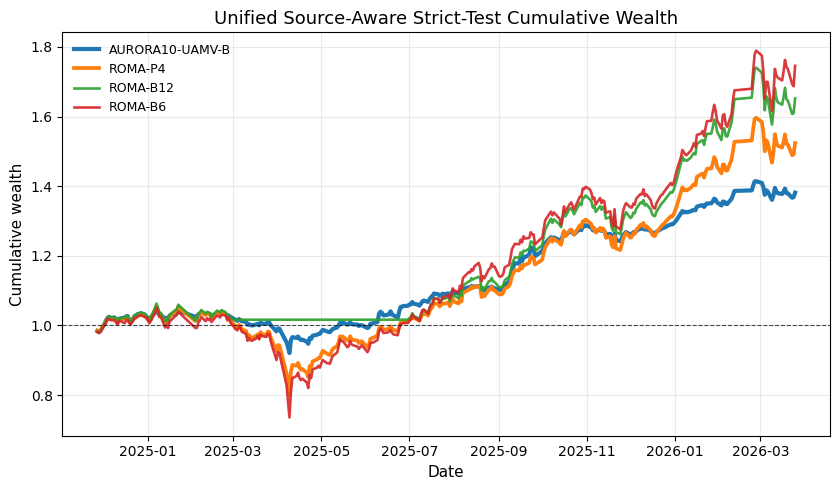

Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/source_aware_unified_paper_comparison/run_20260625_065916/paper_figures/figure_6_5_source_aware_cumulative_wealth.png
Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/source_aware_unified_paper_comparison/run_20260625_065916/paper_figures/figure_6_5_source_aware_cumulative_wealth.pdf


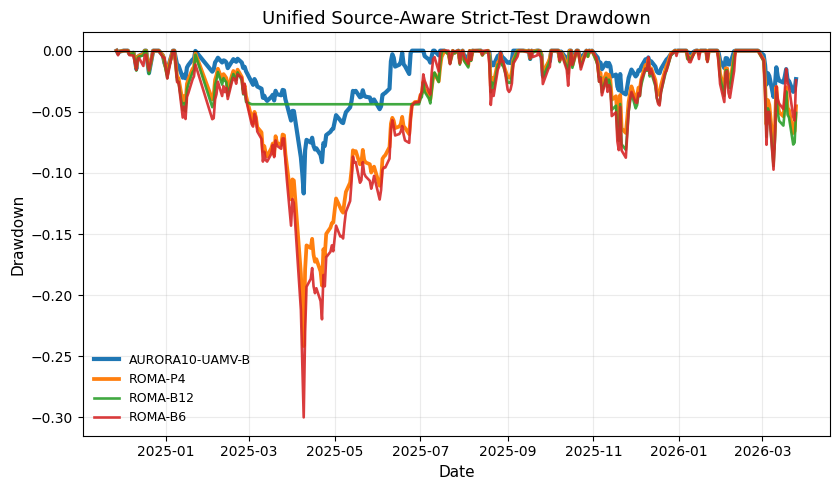

Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/source_aware_unified_paper_comparison/run_20260625_065916/paper_figures/figure_6_6_source_aware_drawdown.png
Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/source_aware_unified_paper_comparison/run_20260625_065916/paper_figures/figure_6_6_source_aware_drawdown.pdf

Summary check:


,strategy,n_days,start_date,end_date,total_return_check,max_drawdown_check
0,AURORA10-UAMV-B,319,2024-11-27,2026-03-25,0.381520,-0.116788
1,ROMA-P4,319,2024-11-27,2026-03-25,0.524028,-0.241634
2,ROMA-B12,319,2024-11-27,2026-03-25,0.652240,-0.094307
3,ROMA-B6,319,2024-11-27,2026-03-25,0.745921,-0.300012



Exported plotted data:
/content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/source_aware_unified_paper_comparison/run_20260625_065916/paper_figures/figure_6_5_source_aware_cumulative_wealth_data.csv
/content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/source_aware_unified_paper_comparison/run_20260625_065916/paper_figures/figure_6_6_source_aware_drawdown_data.csv
/content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/source_aware_unified_paper_comparison/run_20260625_065916/paper_figures/figure_6_5_6_6_source_aware_summary_check.csv


In [1]:
# =============================================================================
# Generate Figure 6.5 and Figure 6.6
# Section 6.5 Unified source-aware comparison
#
# Source:
# notebook13B_source_aware_strict_test_return_matrix.parquet
#
# Outputs:
# Figure 6.5: Source-aware cumulative wealth comparison
# Figure 6.6: Source-aware drawdown comparison
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 0. Colab setup
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Google Drive mount skipped or failed.")


# =============================================================================
# 1. Paths and configuration
# =============================================================================

RETURNS_PATH = Path(
    "/content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/"
    "source_aware_unified_paper_comparison/run_20260625_065916/returns/"
    "notebook13B_source_aware_strict_test_return_matrix.parquet"
)

OUT_DIR = Path(
    "/content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/"
    "source_aware_unified_paper_comparison/run_20260625_065916/paper_figures"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)

STRICT_START = "2024-11-27"
STRICT_END = "2026-03-25"

# Cleaner four-line version for the main paper
# This directly supports the main comparison:
# AURORA10-UAMV-B vs ROMA-P4, with key benchmarks.
PLOT_STRATEGIES = [
    "AURORA10_UAMV_B_more60_defensive",
    "ROMA_P4_balanced_regime_blend",
    "ROMA_B12_ma_timing_equal_weight",
    "ROMA_B6_00881_only",
]

LABEL_MAP = {
    "AURORA10_UAMV_B_more60_defensive": "AURORA10-UAMV-B",
    "ROMA_P4_balanced_regime_blend": "ROMA-P4",
    "ROMA_B12_ma_timing_equal_weight": "ROMA-B12",
    "ROMA_B6_00881_only": "ROMA-B6",
}

# Optional: use a slightly larger comparison set.
# Uncomment this block if you want more lines in the figures.
"""
PLOT_STRATEGIES = [
    "AURORA10_UAMV_B_more60_defensive",
    "ROMA_P4_balanced_regime_blend",
    "ROMA_P2_20d_only_return_seeking",
    "ROMA_B12_ma_timing_equal_weight",
    "ROMA_B6_00881_only",
    "AURORA_B12_ma_timing_equal_weight",
    "AURORA_B6_00881_only",
]

LABEL_MAP = {
    "AURORA10_UAMV_B_more60_defensive": "AURORA10-UAMV-B",
    "ROMA_P4_balanced_regime_blend": "ROMA-P4",
    "ROMA_P2_20d_only_return_seeking": "ROMA-P2",
    "ROMA_B12_ma_timing_equal_weight": "ROMA-B12",
    "ROMA_B6_00881_only": "ROMA-B6",
    "AURORA_B12_ma_timing_equal_weight": "AURORA-B12",
    "AURORA_B6_00881_only": "AURORA-B6",
}
"""


# =============================================================================
# 2. Helper functions
# =============================================================================

def load_source_aware_returns(path: Path) -> pd.DataFrame:
    """
    Load Notebook 13B source-aware strict-test return matrix.

    Handles:
    1. Wide matrix: date index, one strategy per column.
    2. Wide matrix with date column.
    3. Long table: date / policy_name / return column.
    """

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_parquet(path)

    print("Raw file loaded")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Head:")
    display(df.head())

    df = df.copy()

    # Case 1: date stored as a column
    date_candidates = ["date", "Date", "datetime", "timestamp", "trade_date"]
    date_col = next((c for c in date_candidates if c in df.columns), None)

    # Case 2: possible long-format columns
    policy_candidates = [
        "policy_name", "strategy", "strategy_name",
        "display_name", "column", "name"
    ]
    return_candidates = [
        "return", "returns", "daily_return", "net_return",
        "strategy_return", "portfolio_return", "ret"
    ]

    policy_col = next((c for c in policy_candidates if c in df.columns), None)
    return_col = next((c for c in return_candidates if c in df.columns), None)

    # Long format
    if date_col is not None and policy_col is not None and return_col is not None:
        print("\nDetected long-format return table.")
        print("Date column:", date_col)
        print("Policy column:", policy_col)
        print("Return column:", return_col)

        df[date_col] = pd.to_datetime(df[date_col])

        wide = (
            df.pivot_table(
                index=date_col,
                columns=policy_col,
                values=return_col,
                aggfunc="first"
            )
            .sort_index()
        )
        wide.index.name = "date"
        return wide

    # Wide format with date column
    if date_col is not None:
        print("\nDetected wide-format table with date column.")
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col).sort_index()

        numeric_df = df.select_dtypes(include=[np.number]).copy()
        numeric_df.index.name = "date"
        return numeric_df

    # Wide format with date index
    print("\nAssuming wide-format table with datetime index.")
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df.index.name = "date"

    return numeric_df


def resolve_columns(df: pd.DataFrame, requested_cols: list) -> list:
    """
    Resolve requested strategy names against the columns in the return matrix.
    Allows minor naming variations.
    """
    resolved = []

    for req in requested_cols:
        if req in df.columns:
            resolved.append(req)
            continue

        # Exact string match
        exact = [c for c in df.columns if str(c) == req]
        if len(exact) == 1:
            resolved.append(exact[0])
            continue

        # Try hyphen/underscore normalization
        req_norm = req.lower().replace("-", "_")
        norm_matches = [
            c for c in df.columns
            if str(c).lower().replace("-", "_") == req_norm
        ]
        if len(norm_matches) == 1:
            resolved.append(norm_matches[0])
            continue

        # Substring fallback
        substring_matches = [
            c for c in df.columns
            if req_norm in str(c).lower().replace("-", "_")
            or str(c).lower().replace("-", "_") in req_norm
        ]
        if len(substring_matches) == 1:
            resolved.append(substring_matches[0])
            continue

        print("\nCould not resolve:", req)
        print("Available related columns:")
        related_terms = ["AURORA", "ROMA", "UAMV", "P4", "B12", "B6"]
        related = [
            c for c in df.columns
            if any(term.lower() in str(c).lower() for term in related_terms)
        ]
        print(related)
        raise ValueError(f"Could not resolve requested column: {req}")

    return resolved


def compute_wealth(returns: pd.DataFrame) -> pd.DataFrame:
    """
    Convert daily returns to cumulative wealth.
    """
    return (1.0 + returns.fillna(0.0)).cumprod()


def compute_drawdown(wealth: pd.DataFrame) -> pd.DataFrame:
    """
    Compute drawdown from cumulative wealth.
    """
    return wealth / wealth.cummax() - 1.0


def make_summary(returns: pd.DataFrame) -> pd.DataFrame:
    """
    Quick summary check for plotted series.
    """
    rows = []

    for col in returns.columns:
        r = returns[col].fillna(0.0)
        w = (1.0 + r).cumprod()
        dd = w / w.cummax() - 1.0

        rows.append({
            "strategy": col,
            "n_days": len(r),
            "start_date": r.index.min(),
            "end_date": r.index.max(),
            "total_return_check": w.iloc[-1] - 1.0,
            "max_drawdown_check": dd.min(),
        })

    return pd.DataFrame(rows)


# =============================================================================
# 3. Load and prepare returns
# =============================================================================

returns_all = load_source_aware_returns(RETURNS_PATH)

print("\nPrepared return matrix")
print("Shape:", returns_all.shape)
print("Date range:", returns_all.index.min(), "to", returns_all.index.max())
print("Columns:")
print(returns_all.columns.tolist())

# Filter strict-test period
returns_strict = returns_all.loc[STRICT_START:STRICT_END].copy()

if returns_strict.empty:
    raise ValueError(
        f"No rows found between {STRICT_START} and {STRICT_END}."
    )

print("\nStrict-test return matrix")
print("Shape:", returns_strict.shape)
print("Date range:", returns_strict.index.min(), "to", returns_strict.index.max())

# Resolve strategy columns
resolved_cols = resolve_columns(returns_strict, PLOT_STRATEGIES)

returns_plot = returns_strict[resolved_cols].copy()

# Rename columns for paper figures
rename_map = {
    resolved: LABEL_MAP.get(requested, str(resolved))
    for requested, resolved in zip(PLOT_STRATEGIES, resolved_cols)
}

returns_plot = returns_plot.rename(columns=rename_map)

print("\nSelected plotted series:")
print(returns_plot.columns.tolist())


# =============================================================================
# 4. Compute cumulative wealth and drawdown
# =============================================================================

wealth = compute_wealth(returns_plot)
drawdown = compute_drawdown(wealth)


# =============================================================================
# 5. Figure 6.5: Cumulative wealth
# =============================================================================

plt.figure(figsize=(8.5, 5.0))

for col in wealth.columns:
    if col == "AURORA10-UAMV-B":
        lw = 3.0
        alpha = 1.0
    elif col == "ROMA-P4":
        lw = 2.7
        alpha = 1.0
    else:
        lw = 1.9
        alpha = 0.9

    plt.plot(
        wealth.index,
        wealth[col],
        label=col,
        linewidth=lw,
        alpha=alpha,
    )

plt.axhline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)
plt.title("Unified Source-Aware Strict-Test Cumulative Wealth", fontsize=13)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative wealth", fontsize=11)
plt.legend(frameon=False, fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()

fig65_png = OUT_DIR / "figure_6_5_source_aware_cumulative_wealth.png"
fig65_pdf = OUT_DIR / "figure_6_5_source_aware_cumulative_wealth.pdf"

plt.savefig(fig65_png, dpi=300, bbox_inches="tight")
plt.savefig(fig65_pdf, bbox_inches="tight")
plt.show()

print("Saved:", fig65_png)
print("Saved:", fig65_pdf)


# =============================================================================
# 6. Figure 6.6: Drawdown
# =============================================================================

plt.figure(figsize=(8.5, 5.0))

for col in drawdown.columns:
    if col == "AURORA10-UAMV-B":
        lw = 3.0
        alpha = 1.0
    elif col == "ROMA-P4":
        lw = 2.7
        alpha = 1.0
    else:
        lw = 1.9
        alpha = 0.9

    plt.plot(
        drawdown.index,
        drawdown[col],
        label=col,
        linewidth=lw,
        alpha=alpha,
    )

plt.axhline(0.0, color="black", linewidth=0.8)
plt.title("Unified Source-Aware Strict-Test Drawdown", fontsize=13)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Drawdown", fontsize=11)
plt.legend(frameon=False, fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()

fig66_png = OUT_DIR / "figure_6_6_source_aware_drawdown.png"
fig66_pdf = OUT_DIR / "figure_6_6_source_aware_drawdown.pdf"

plt.savefig(fig66_png, dpi=300, bbox_inches="tight")
plt.savefig(fig66_pdf, bbox_inches="tight")
plt.show()

print("Saved:", fig66_png)
print("Saved:", fig66_pdf)


# =============================================================================
# 7. Export plotted data and summary checks
# =============================================================================

wealth_path = OUT_DIR / "figure_6_5_source_aware_cumulative_wealth_data.csv"
drawdown_path = OUT_DIR / "figure_6_6_source_aware_drawdown_data.csv"
summary_path = OUT_DIR / "figure_6_5_6_6_source_aware_summary_check.csv"

wealth.to_csv(wealth_path)
drawdown.to_csv(drawdown_path)

summary = make_summary(returns_plot)
summary.to_csv(summary_path, index=False)

print("\nSummary check:")
display(summary.round(6))

print("\nExported plotted data:")
print(wealth_path)
print(drawdown_path)
print(summary_path)